In [2]:
from itertools import count

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

from matplotlib.pyplot import subplots_adjust

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)
# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2025_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_h_kxylem"

#scenario_name = "r2000_a20"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_total = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value','psi88_xylem',
              'leaf_hydraulic_capacitance', 'psi50_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0',
              'jackson_root_beta', 'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation', 'g_bark']

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem','psi88_xylem',
              'g0', 'jackson_root_beta', 'g_bark']

df = pd.read_csv(os.path.join(post_path, "aggregated_out.csv"))
df.sort_values(by=['RMSE_MAX'], inplace=True, ascending=True)
# df = df[df['RMSE_MAX'] < 1.1]
# index_to_drop = df[(df['sid'] == 2) | (df['sid'] == 2)].index
#df.drop(index_to_drop, inplace=True)
df_mean = df.groupby(['id'])[vars_total].mean()

In [3]:
df

,Unnamed: 0,index,id,dts,dts_input,verbose,max_psi_leaf_change_per_hour,minimum_psi_leaf_multiplier,conductivity_fraction_type,anet_max,...,t8,t9,t10,t11,t12,t13,alive_mean,target_rmse,RMSE_MAX,sid
47796,0,4600,11949,1800.0,1800,False,1.0,4.0,Weibull,0.606484,...,0.350244,0.336460,0.399313,0.393564,0.447204,0.357815,0.405520,0.801860,0.899789,0
47797,1,8057,11949,1800.0,1800,False,1.0,4.0,Weibull,0.584856,...,3.645808,4.067239,2.217345,2.391593,2.194544,2.140024,2.518467,0.801860,0.899789,1
47798,2,2539,11949,1800.0,1800,False,1.0,4.0,Weibull,0.489144,...,16.599797,16.786633,9.256771,9.674233,9.240457,9.137213,10.384697,0.801860,0.899789,2
47799,3,6608,11949,1800.0,1800,False,1.0,4.0,Weibull,0.521454,...,18.557685,18.745920,11.380099,11.917945,11.356959,11.340658,12.524362,0.801860,0.899789,3
91979,3,3161,22994,1800.0,1800,False,1.0,4.0,Weibull,0.848179,...,18.080128,18.268051,11.089863,11.616998,11.065857,11.050371,12.205835,0.791841,0.901002,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99603,3,2352,24900,1800.0,1800,False,1.0,4.0,Weibull,0.763656,...,4.158843,4.923281,3.001581,3.237758,2.953470,2.923177,3.325607,1.096636,1.625332,3
88148,0,9827,22037,1800.0,1800,False,1.0,4.0,Weibull,0.877178,...,0.325854,0.290468,0.398088,0.368417,0.439083,0.372387,0.389796,1.096400,1.645795,0
88150,2,8249,22037,1800.0,1800,False,1.0,4.0,Weibull,1.113920,...,0.505009,1.723773,1.003605,1.116922,0.962699,0.901159,1.134292,1.096400,1.645795,2
88151,3,8533,22037,1800.0,1800,False,1.0,4.0,Weibull,0.966767,...,2.849538,3.278284,2.187308,2.403585,2.118964,2.105501,2.390274,1.096400,1.645795,3


In [4]:
df_norm = (df_mean - df_mean.mean()) / df_mean.std()

In [5]:
df_norm[vars_plant]

,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,jackson_root_beta,g_bark
id,,,,,,,,,
0,-0.599621,1.334192,0.530465,1.352667,0.013958,0.127986,-1.077822,-0.866785,-0.876087
1,-0.233956,-0.746228,-0.004425,-0.790133,-0.134043,0.869565,-1.483671,0.001961,-1.054802
2,-1.050224,0.807407,-0.800347,-1.012256,0.671267,-0.260404,-1.250020,0.573422,-1.486249
3,1.459944,0.655987,0.545121,-0.352396,1.662569,1.619512,1.448598,1.360006,0.927611
4,0.866764,-1.031627,0.403552,-0.661565,-0.133492,0.340700,-0.239052,-0.319920,0.605998
...,...,...,...,...,...,...,...,...,...
28311,0.899684,-0.643670,-0.094696,0.026391,0.925606,1.355661,-0.764521,0.499794,-0.889475
28312,-0.284973,0.311868,0.494529,-0.326785,0.702081,1.214435,-1.206690,0.866256,-0.755236
28313,0.952228,-0.293357,0.772645,2.389883,0.761075,1.350178,0.601500,-0.343634,0.538168


In [6]:
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score

In [7]:
vars_sel = ['stem_hydraulic_capacitance', 'k_xylem_sat','huber_value', 'psi50_xylem','g0', ]
label_dict  = {}
label_dict['huber_value'] = r"Huber"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Stem}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['k_xylem_sat'] = r"$K_\mathrm{xyl, max}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_leaf_50_close'] = r"$\psi_{Leaf, close}$"
label_dict['g_bark'] = r"$g_\mathrm{Stem}$"
label_dict['anet_max'] = r"$\mathrm{A_{max}}$"


unit_dict= {}
unit_dict['stem_hydraulic_capacitance'] = "kg m-3 MPa-1"
unit_dict['k_xylem_sat'] = "kg m-1 s-1 MPa-1"
unit_dict['huber_value'] = "-"
unit_dict['psi50_xylem'] = "MPa"
unit_dict['g0'] = "mol m-1 s-1"
unit_dict['g_bark'] = "mol m-1 s-1"


In [8]:
df_norm

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,psi88_xylem,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark
id,,,,,,,,,,,,,,,,,,
0,0.627294,0.124630,-0.599621,1.334192,0.530465,0.127986,1.352667,0.013958,-1.077822,1.537087,-1.207035,0.690515,-0.866785,0.475343,-1.073061,1.076073,-0.883831,-0.876087
1,1.425347,-1.304653,-0.233956,-0.746228,-0.004425,0.869565,-0.790133,-0.134043,-1.483671,1.034021,1.523949,-0.138617,0.001961,-0.493834,0.520206,-0.888566,-1.148805,-1.054802
2,-0.647166,-1.068013,-1.050224,0.807407,-0.800347,-0.260404,-1.012256,0.671267,-1.250020,0.172953,0.918781,-0.394443,0.573422,0.408856,-1.215252,1.232412,-1.245024,-1.486249
3,-0.518629,-1.213398,1.459944,0.655987,0.545121,1.619512,-0.352396,1.662569,1.448598,-0.876700,1.360347,-0.110814,1.360006,0.045875,-1.356361,1.580140,-0.868046,0.927611
4,0.170446,0.768506,0.866764,-1.031627,0.403552,0.340700,-0.661565,-0.133492,-0.239052,-1.470709,0.537658,-0.084527,-0.319920,-0.948402,-0.262646,-0.176927,-0.398224,0.605998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28311,-0.612326,-0.863816,0.899684,-0.643670,-0.094696,1.355661,0.026391,0.925606,-0.764521,0.014404,-0.203318,-0.272013,0.499794,-1.222778,-1.666281,0.776048,-1.195546,-0.889475
28312,-0.342336,-0.908194,-0.284973,0.311868,0.494529,1.214435,-0.326785,0.702081,-1.206690,0.139501,1.192324,-0.900772,0.866256,-0.951720,-1.081582,0.040240,-1.333359,-0.755236
28313,1.253440,1.226881,0.952228,-0.293357,0.772645,1.350178,2.389883,0.761075,0.601500,1.834781,0.863679,-0.977465,-0.343634,-1.076051,-0.374169,0.597334,-0.496549,0.538168


In [9]:
kmeans = KMeans(n_clusters = 3, random_state = 0, n_init='auto')
kmeans.fit(df_norm[vars_plant])

KMeans(n_clusters=3, random_state=0)

In [10]:
K = range(2, 12)
fits = []

scorss = []
for s in range(2):
    score = []
    for k in K:
        # train the model for current value of k on training data
        model = KMeans(n_clusters = k, random_state = s, n_init='auto').fit(df_norm[vars_sel])

        # append the model to fits
        fits.append(model)

        # Append the silhouette score to scores
        score.append(silhouette_score(df_norm[vars_sel], model.labels_, metric='euclidean'))
    scorss.append(score)
    print(s)


0
1


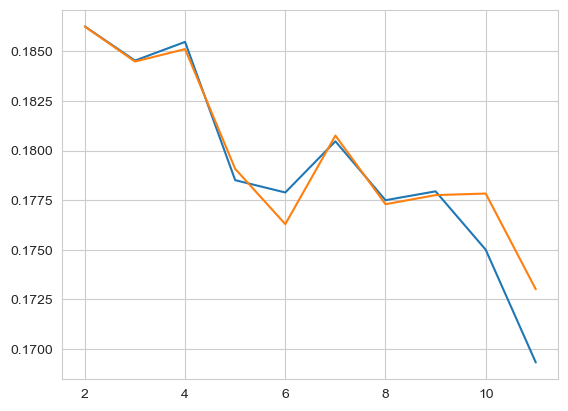

In [11]:
plt.plot(K, np.array(scorss).T);

In [12]:
kmeans = KMeans(n_clusters = 4, random_state = 9
                , n_init='auto')
kmeans.fit(df_norm[vars_sel])
np.round(silhouette_score(df_norm[vars_sel], kmeans.labels_, metric='euclidean'),3)


0.185

In [13]:
unique, counts = np.unique(kmeans.labels_, return_counts=True)
counts
countslabs = [f'G{i+1} ({counts[i]})'for i in range(4)]


In [14]:
vars_sel

['stem_hydraulic_capacitance',
 'k_xylem_sat',
 'huber_value',
 'psi50_xylem',
 'g0']

/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_23099/3063519254.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_23099/3063519254.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_23099/3063519254.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/var/folders/9r/97b9zk_j4ys8v5lnksc4l4j00000gq/T/ipykernel_23099/3063519254.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(countslabs)
/var/folders/9r/97b9zk_j4ys8

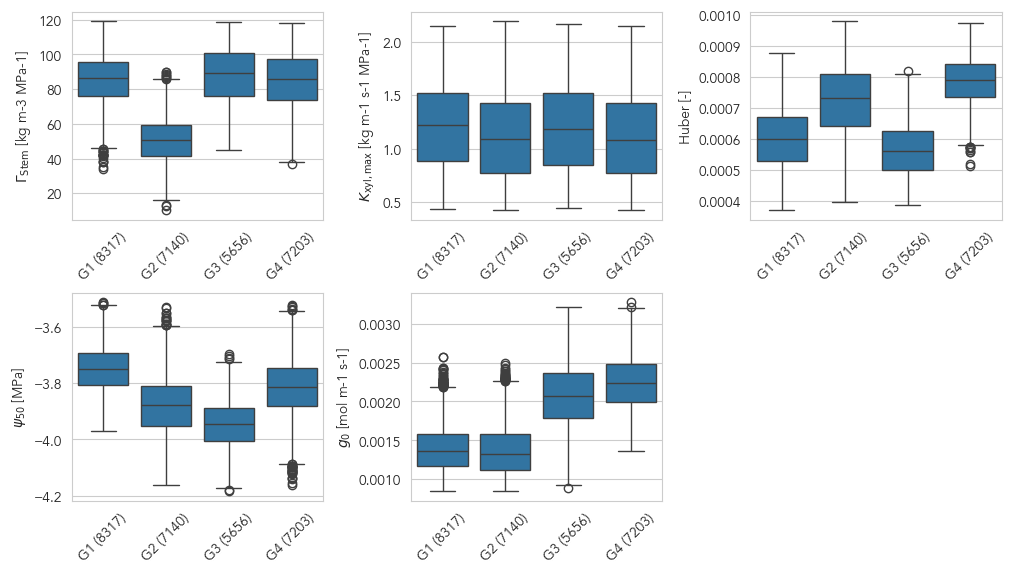

In [15]:
MOL_TO_KG = 18.0/1000.0
plt.rcParams["font.family"] = "Avenir"
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, 5+1), vars_sel):
    ax = fig.add_subplot(3,3, index)
    ax.set_xticklabels(countslabs)
    ax.set_ylabel(f"{label_dict[vars_sel[index-1]]} [{unit_dict[vars_sel[index-1]]}]")
    
    if  var == 'stem_hydraulic_capacitance':
        sns.boxplot(x = kmeans.labels_, y = df_mean[var] * MOL_TO_KG, ax=ax)
    elif var == 'k_xylem_sat':
        sns.boxplot(x = kmeans.labels_, y = df_mean[var] * MOL_TO_KG, ax=ax)
    else:
        sns.boxplot(x = kmeans.labels_, y = df_mean[var], ax=ax)
    ax.tick_params(axis='x', labelrotation=45)

plt.subplots_adjust(wspace=0.35, hspace=0.35)
plt.savefig(f"{post_path}/figure4_kmeans_cluster.png", bbox_inches='tight', dpi = 300)

In [16]:
from sklearn.cluster import MeanShift
from sklearn import metrics

db = MeanShift(bandwidth=2).fit(df_norm[vars_plant])

labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print(f"Silhouette Coefficient: {metrics.silhouette_score(df_norm[vars_plant], db.labels_,metric='euclidean'):.3f}")

Estimated number of clusters: 5
Estimated number of noise points: 0
Silhouette Coefficient: 0.041


In [16]:
df_norm[vars_plant]

,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,jackson_root_beta
id,,,,,,,,
0,-0.601464,1.145214,0.593686,1.227873,-2.142011,-2.047083,-0.991387,-0.736660
1,-0.505121,-0.872027,-0.098686,-0.794584,1.755737,1.980279,-1.392011,0.734571
2,1.412511,0.534290,0.514407,-0.280269,1.284822,1.306727,1.622993,2.429507
3,0.598750,-0.964184,0.907454,-0.669782,0.260972,1.040270,0.425506,0.440895
4,-0.263877,0.727996,0.548335,1.939314,0.978791,0.045805,0.180179,-0.495927
...,...,...,...,...,...,...,...,...
23694,-0.113747,0.276975,1.328484,1.707235,-0.075766,0.262491,2.640747,-1.652910
23695,-0.601057,-0.126646,-0.997181,-0.805152,1.175334,0.476110,-0.954902,0.152204
23696,0.553392,0.628877,0.964663,0.057998,0.602677,1.493658,0.034281,0.840595


In [ ]:
unique, counts = numpy.unique(a, return_counts=True)

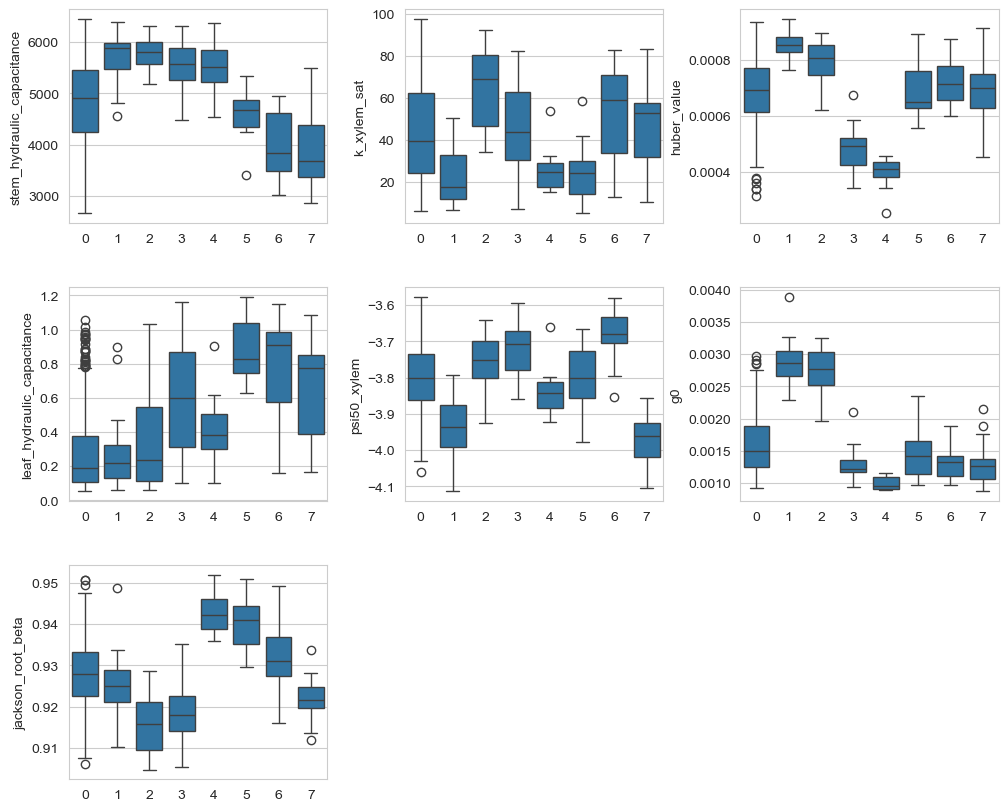

In [40]:
fig = plt.figure(figsize = (12,10))
for index,  var in zip(np.arange(1, len(vars_plant)+1), vars_plant):
    ax = fig.add_subplot(3,3, index)
    sns.boxplot(x = labels, y = df_mean[var], ax=ax)
fig.subplots_adjust(wspace=0.3, hspace=0.3)

<Axes: >

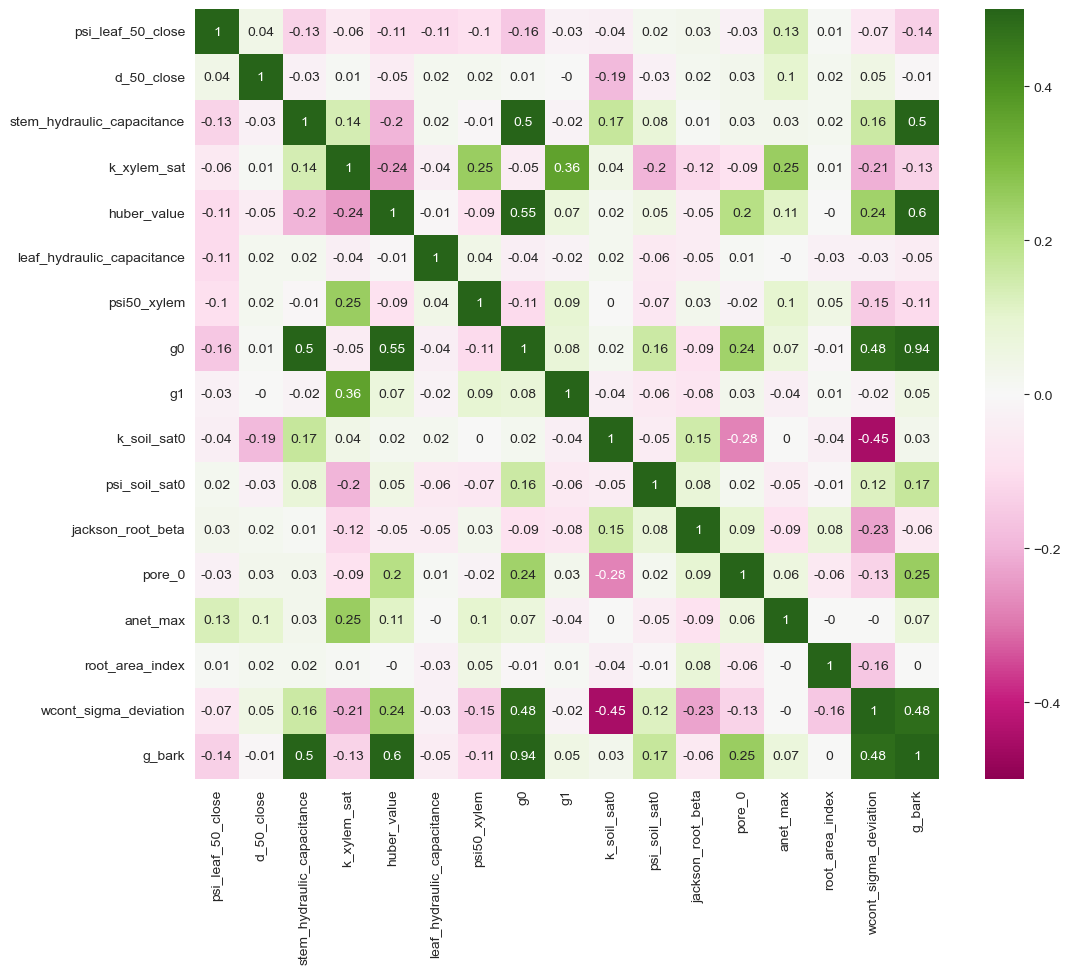

In [39]:
corr_matrix = df_mean.corr(method='spearman').round(2)
#corr_matrix.style.background_gradient(cmap='Greens')
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot=True, vmin=-0.5, vmax=0.5, cmap="PiYG")